# On Analyzing Real World Time Series using the Wesad Dataset

[WESAD (Wearable Stress and Affect Detection)](https://archive.ics.uci.edu/dataset/465/wesad+wearable+stress+and+affect+detection)

In [1]:
import os
import sleepecg
import statsmodels

import numpy as np
import pandas as pd
import neurokit2 as nk

import wfdb.processing

from tqdm import tqdm

from scipy.signal import butter, lfilter

from statsmodels.robust.scale import mad

# Get the current working directory of the notebook
notebook_dir = os.getcwd()

In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load Chest and Wrist Data

- Synchronised raw sensor data and labels

### Data Attributes

- Chest: RespiBAN device
    - Sampled at 700 Hz
    1. **ACC_x:**
    2. **ACC_y:**
    3. **ACC_z:**
    4. **ECG:**
    5. **EMG:**
    6. **EDA:**
    7. **Temp:**
    8. **Resp:**
    9. **Subject:** The participant in the study
    10. **Label:** ID of the respective study protocol condition
        - 0 = not defined / transient
        - 1 = baseline
        - 2 = stress
        - 3 = amusement
        - 4 = meditation
        - 5/6/7 = should be ignored in this dataset
- Wrist: Empatica E4 device


In [3]:
def build_wesad() -> list[pd.DataFrame]:
    """Load the WESAD Dataset"""
    base_path = "../../"
    
    chest_dataset_path = "roeh-health/data/WESAD/all_subjects/chest.csv"
    wrist_dataset_path = "roeh-health/data/WESAD/all_subjects/wrist.csv"
    
    chest_relative_path = os.path.join(base_path, chest_dataset_path)
    wrist_relative_path = os.path.join(base_path, wrist_dataset_path)

    chest_df = pd.read_csv(chest_relative_path)
    wrist_df = pd.read_csv(wrist_relative_path)

    chest_df.drop(['Unnamed: 0'], axis=1, inplace=True)
    wrist_df.drop(['Unnamed: 0'], axis=1, inplace=True)

    return chest_df, wrist_df

In [4]:
chest_df, wrist_df = build_wesad()

## Get ECG

In [5]:
chest_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [6]:
ecg_df = chest_df.loc[:, ['ECG', 'subject', 'label']]
ecg_df

,ECG,subject,label
0,0.021423,S2,0
1,0.020325,S2,0
2,0.016525,S2,0
3,0.016708,S2,0
4,0.011673,S2,0
...,...,...,...
60807595,0.173676,S17,0
60807596,0.168777,S17,0
60807597,0.167130,S17,0
60807598,0.170334,S17,0


## Specific Subject

In [7]:
filt_s2 = (ecg_df['subject'] == 'S2')
s2_df = ecg_df[filt_s2]
s2_df.dropna(inplace=True)
s2_df

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_24618/3120572741.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s2_df.dropna(inplace=True)


,ECG,subject,label
0,0.021423,S2,0
1,0.020325,S2,0
2,0.016525,S2,0
3,0.016708,S2,0
4,0.011673,S2,0
...,...,...,...
4255295,-0.013138,S2,0
4255296,-0.010345,S2,0
4255297,-0.005447,S2,0
4255298,0.000137,S2,0


In [8]:
s2_values = s2_df['ECG'].values
s2_values

array([ 0.02142334,  0.02032471,  0.01652527, ..., -0.00544739,
        0.00013733,  0.0040741 ], shape=(4255300,))

## Signals and RPeaks

In [9]:
s2_sigals_and_rpeaks = nk.ecg_process(s2_values, 700)
s2_sigals_df = s2_sigals_and_rpeaks[0]
rpeaks = s2_sigals_and_rpeaks[1]

In [10]:
s2_sigals_df

,ECG_Raw,ECG_Clean,ECG_Rate,ECG_Quality,ECG_R_Peaks,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_R_Onsets,ECG_R_Offsets,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets,ECG_Phase_Atrial,ECG_Phase_Completion_Atrial,ECG_Phase_Ventricular,ECG_Phase_Completion_Ventricular
0,0.021423,-0.030088,71.823646,0.903204,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1,0.020325,-0.032014,71.823646,0.903204,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
2,0.016525,-0.033976,71.823646,0.903204,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
3,0.016708,-0.035979,71.823646,0.903204,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
4,0.011673,-0.038059,71.823646,0.903204,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4255295,-0.013138,-0.001854,59.659091,0.926369,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
4255296,-0.010345,-0.000007,59.659091,0.926369,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
4255297,-0.005447,0.002147,59.659091,0.926369,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
4255298,0.000137,0.004531,59.659091,0.926369,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0


## ECG Plot

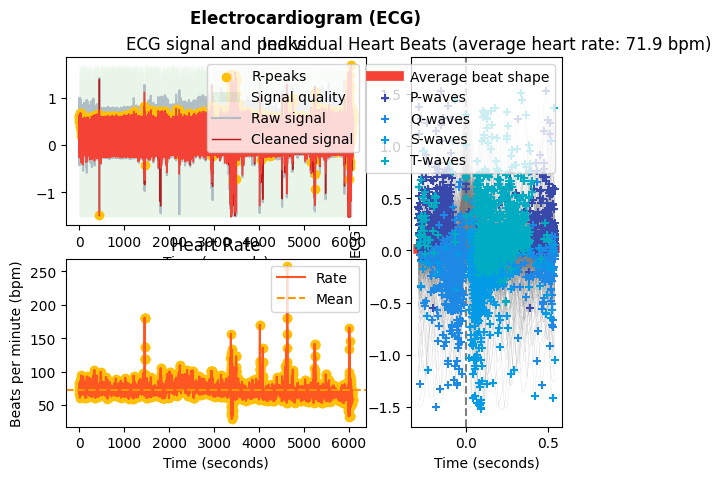

In [11]:
nk.ecg_plot(s2_sigals_df, rpeaks)

In [12]:
nk.ecg_analyze(s2_sigals_df, 700, 'interval-related')

,ECG_Rate_Mean,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,71.902895,[[835.3794796269024]],[[105.82339195528374]],[[54.95748045524939]],[[80.00147513141057]],[[52.16299224397841]],[[85.11797800447492]],[[47.24064649352364]],[[87.24916329671339]],[[83.26143457046706]],...,[[1.4308403082654144]],[[8.06702211865153]],[[0.9288725659121595]],[[1.2637294694178867]],[[1.4479302690953453]],[[2.014748377085085]],[[1.116786905648008]],[[1.7651747144751562]],[[2.660817137218707]],[[0.7106500079273199]]


(      ECG_R_Peaks
 0               0
 1               0
 2               0
 3               0
 4               0
 ...           ...
 3296            0
 3297            0
 3298            0
 3299            0
 3300            0
 
 [3301 rows x 1 columns],
 {'method_peaks': 'neurokit',
  'method_fixpeaks': 'None',
  'ECG_R_Peaks': array([ 699, 1208, 1745, 2378, 3002]),
  'ECG_R_Peaks_Uncorrected': array([ 699, 1208, 1745, 2378, 3002]),
  'ECG_fixpeaks_ectopic': [],
  'ECG_fixpeaks_missed': [],
  'ECG_fixpeaks_extra': [],
  'ECG_fixpeaks_longshort': [],
  'ECG_fixpeaks_method': 'kubios',
  'ECG_fixpeaks_rr': array([0.8225    , 0.72714286, 0.76714286, 0.90428571, 0.89142857]),
  'ECG_fixpeaks_drrs': array([ 0.08483516, -0.46945055,  0.19692308,  0.67516484, -0.0632967 ]),
  'ECG_fixpeaks_mrrs': array([ 0.        , -1.75542406, -1.0190664 ,  0.75279421,  0.63445102]),
  'ECG_fixpeaks_s12': array([-0.46945055,  0.08483516,  0.67516484,  0.19692308,  0.67516484]),
  'ECG_fixpeaks_s22': array

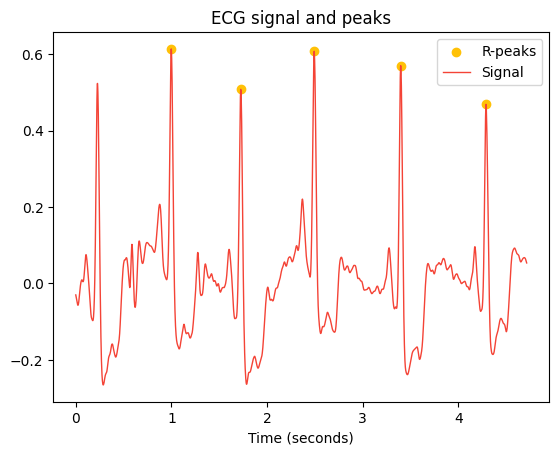

In [20]:
nk.ecg_peaks(s2_sigals_df.loc[:3300, 'ECG_Clean'], sampling_rate=700, correct_artifacts=True, show=True)

## Delineate

(      ECG_P_Peaks  ECG_P_Onsets  ECG_P_Offsets  ECG_Q_Peaks  ECG_R_Onsets  \
 0               0             0              0            0             0   
 1               0             0              0            0             0   
 2               0             0              0            0             0   
 3               0             0              0            0             0   
 4               0             0              0            0             0   
 ...           ...           ...            ...          ...           ...   
 3296            0             0              0            0             0   
 3297            0             0              0            0             0   
 3298            0             0              0            0             0   
 3299            0             0              0            0             0   
 3300            0             0              0            0             0   
 
       ECG_R_Offsets  ECG_S_Peaks  ECG_T_Peaks  ECG_T_Onsets  

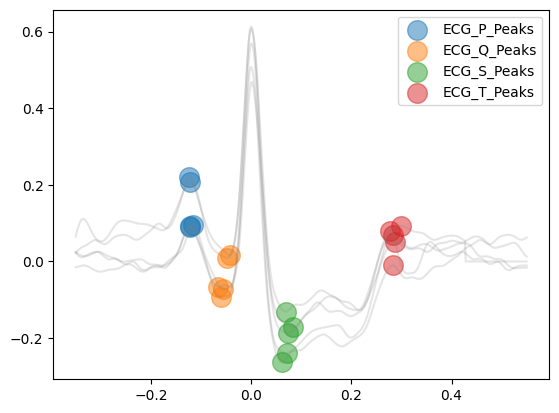

In [26]:
nk.ecg_delineate(s2_sigals_df.loc[:3300 , 'ECG_Clean'], sampling_rate=700, show=True)

## Phase

In [28]:
nk.ecg_phase(s2_sigals_df.loc[:3300, 'ECG_Clean'], sampling_rate=700)

,ECG_Phase_Atrial,ECG_Phase_Completion_Atrial,ECG_Phase_Ventricular,ECG_Phase_Completion_Ventricular
0,NaN,0.0,NaN,0.0
1,NaN,0.0,NaN,0.0
2,NaN,0.0,NaN,0.0
3,NaN,0.0,NaN,0.0
4,NaN,0.0,NaN,0.0
...,...,...,...,...
3296,NaN,0.0,NaN,0.0
3297,NaN,0.0,NaN,0.0
3298,NaN,0.0,NaN,0.0
3299,NaN,0.0,NaN,0.0
